In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutil

In [2]:
im = cv2.imread("E:\\test2.jpg")
im_gray = cv2.cvtColor(im,cv2.COLOR_BGR2GRAY)
noise_removal = cv2.bilateralFilter(im_gray,9,75,75)
equal_histogram = cv2.equalizeHist(noise_removal)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))
morph_image = cv2.morphologyEx(equal_histogram,cv2.MORPH_OPEN,kernel,iterations=20)
sub_morp_image = cv2.subtract(equal_histogram,morph_image)
ret,thresh_image = cv2.threshold(sub_morp_image,0,255,cv2.THRESH_OTSU)
canny_image = cv2.Canny(thresh_image,250,255)
kernel = np.ones((3,3), np.uint8)
dilated_image = cv2.dilate(canny_image,kernel,iterations=1)

In [3]:
contours, hierarchy = cv2.findContours(dilated_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours= sorted(contours, key = cv2.contourArea, reverse = True)[:10]
screenCnt = None
for c in contours:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.06 * peri, True) 
    if len(approx) == 4:
            screenCnt = approx
            break

In [4]:
screenCnt

array([[[404, 336]],

       [[522, 335]],

       [[517, 418]],

       [[401, 418]]], dtype=int32)

In [5]:
mask = np.zeros(im_gray.shape, np.uint8)
new_image = cv2.drawContours(mask, [screenCnt], 0, 255, -1)
new_image = cv2.bitwise_and(im, im, mask=mask)

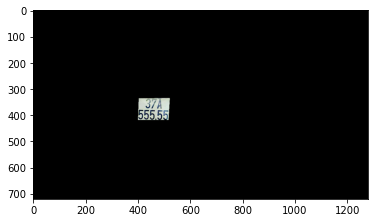

In [6]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))

In [7]:
(x,y) = np.where(mask==255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
cropped_image = im_gray[x1:x2+1, y1:y2+1]

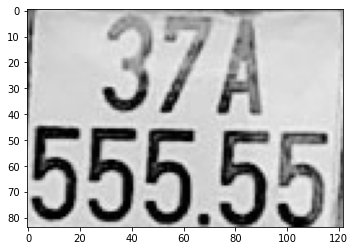

In [8]:
plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))

In [9]:
import easyocr

In [10]:
reader = easyocr.Reader(['en'])
result = reader.readtext(cropped_image)
result

CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
C:\Users\DELL\anaconda3\lib\site-packages\torch\nn\functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  ..\c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


[([[22, 0], [100, 0], [100, 46], [22, 46]], '37A', 0.543571583124279),
 ([[0, 37], [122, 37], [122, 84], [0, 84]], '555.55', 0.6844237664267218)]

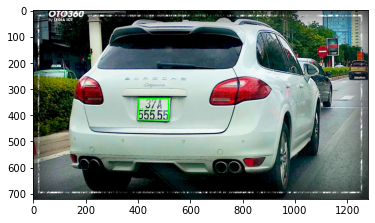

In [11]:
text = result[0][-2]
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(im, text=text, org=(approx[0][0][0], approx[1][0][1]+60), fontFace=font, fontScale=1, color=(0,255,0), lineType=cv2.LINE_AA)
res = cv2.rectangle(im, tuple(approx[0][0]), tuple(approx[2][0]), (0,255,0),3)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))